In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios
from sklearn.model_selection import train_test_split

from formulaic import Formula

## Pregunta 4

Utilizando el dataset penguins, calcular:
<ol>
<li>Peso promedio de los pingüinos de la especie Adelie</li>
<li>Peso promedio de los pingüinos de la especie Adelie que viven en la Isla Dream</li>
<li>Para cada isla, el desvío estándar del peso de los pingüinos que viven en esa isla</li>
</ol>

In [31]:
penguins= sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [33]:
penguins_Adelie= penguins[penguins["species"]=="Adelie"]

penguins_Adelie.dropna().reset_index(drop=True)

peso_medio_adelie = penguins_Adelie["body_mass_g"].mean()

print(f"Peso medio adelie: {peso_medio_adelie:.2f}")

Peso medio adelie: 3700.66


In [19]:
# Peso promedio de los pingüinos de la especie Adelie que viven en la Isla Dream

adelie_dream = penguins_Adelie[penguins_Adelie["island"]== "Dream"]

peso_medio_adelie_dream = adelie_dream["body_mass_g"].mean()

print(f"Peso medio de los pingüinos Adelie en la isla Dream: {peso_medio_adelie_dream:.2f}")

Peso medio de los pingüinos Adelie en la isla Dream: 3688.39


In [28]:
# Para cada isla el desvío estandar del peso de los pingüinos que viven en esa isla

penguins["island"].value_counts()

penguinsClean = penguins.dropna().reset_index(drop=True)
penguinsClean

desvio_estandar_peso_tor= penguinsClean[penguinsClean["island"]=='Torgersen']["body_mass_g"].std()
desvio_estandar_peso_biscoe= penguinsClean[penguinsClean["island"]=='Biscoe']["body_mass_g"].std()
desvio_estandar_peso_dream= penguinsClean[penguinsClean["island"]=='Dream']["body_mass_g"].std()

print(f"Desvío estándar peso isla Torgersen: {desvio_estandar_peso_tor}")
print(f"Desvío estándar peso isla Biscoe: {desvio_estandar_peso_biscoe}")
print(f"Desvío estándar peso isla Dream: {desvio_estandar_peso_dream}")

Desvío estándar peso isla Torgersen: 451.8463509694045
Desvío estándar peso isla Biscoe: 790.8600693688636
Desvío estándar peso isla Dream: 412.935580548016


## Ejercicio 7
Ingresar un código para generar el siguiente gráfico a partir de los datos de Gapminder

(Es un gráfico de línea de gdpPercap vs año para los 4 países : Argentina, Chile, Uruguay, Brasil)

In [35]:
gapminder = pd.read_csv('../../datasets/gapminder.csv')
gapminder

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


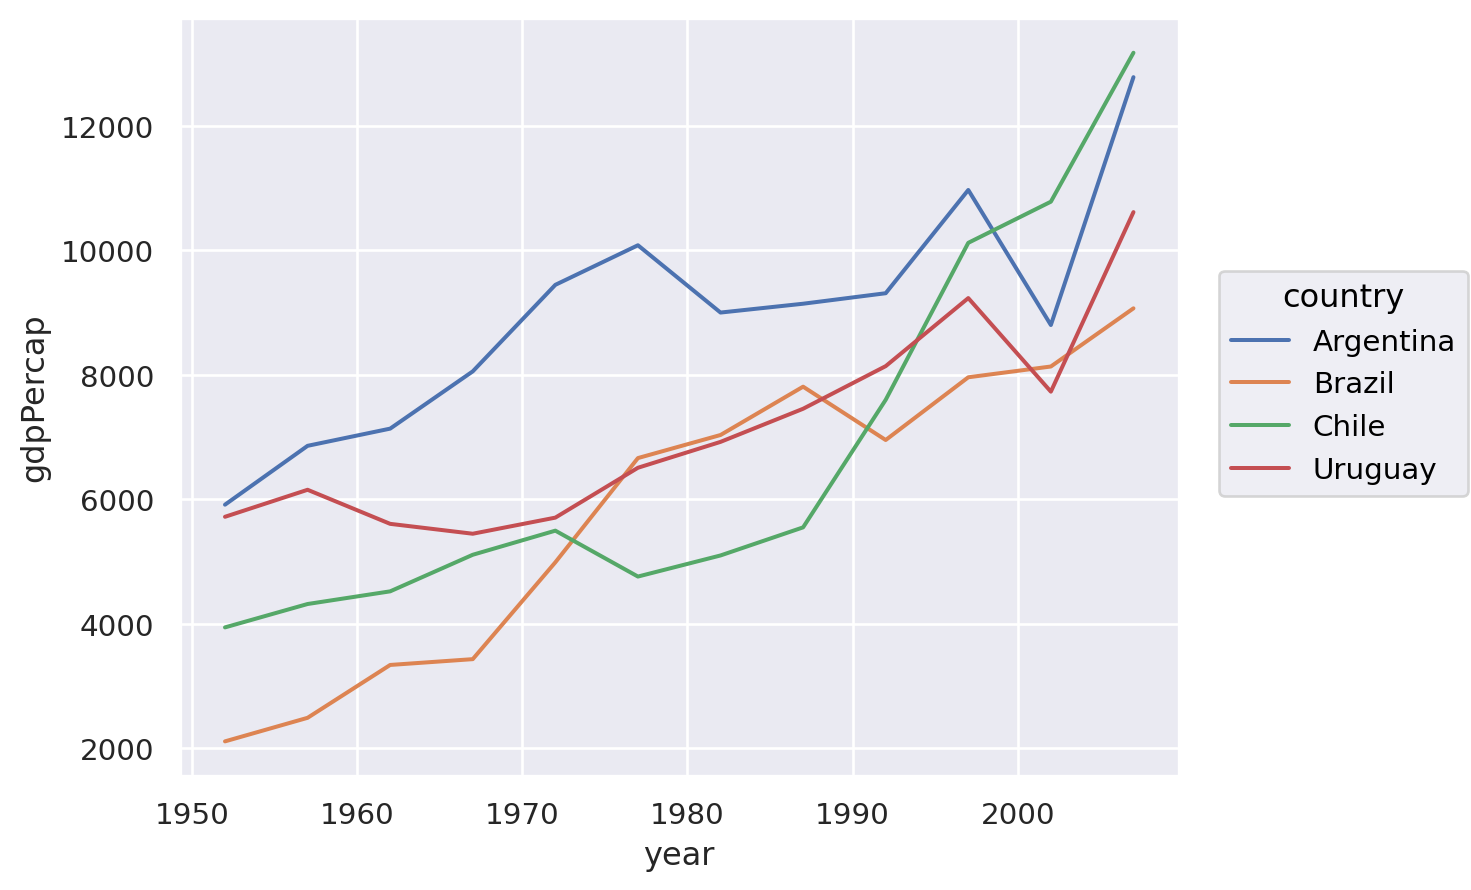

In [39]:
arg_chi_bra_uru = gapminder[gapminder["country"].isin(["Argentina","Chile","Brazil","Uruguay"])]

(
    so.Plot(arg_chi_bra_uru, x ="year",y="gdpPercap", color= "country")
    .add(so.Line())
)